In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from boruta import BorutaPy

import warnings
warnings.filterwarnings('ignore')

In [3]:
# For reproducibility
np.random.seed(123)

In [13]:
df = pd.read_stata("encoded_bd.dta")
df.head()

,Division,residence,Respondent_education,wealth_index,distance_Health_facility,partner_education,religion_cat,dropout_MNCH,age_grp,husband_age_grp,occ_working,birth_order_cat,wanted_last_child,preg_loss,media_exposure,women_autonomy_cat,hh_size_cat
0,barishal,1,3,4,2,3.0,2.0,0.0,3.0,4.0,1.0,3.0,1.0,1.0,1.0,1.0,2
1,barishal,1,2,4,1,2.0,2.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,1
2,barishal,1,3,5,2,3.0,2.0,0.0,2.0,2.0,0.0,1.0,1.0,1.0,1.0,3.0,2
3,barishal,1,3,4,1,2.0,2.0,0.0,2.0,3.0,1.0,2.0,1.0,0.0,1.0,3.0,1
4,barishal,1,3,5,2,3.0,2.0,0.0,1.0,2.0,0.0,1.0,1.0,0.0,1.0,3.0,2


In [15]:
df.shape

(5055, 17)

In [17]:
df.isnull().sum()

Division                     0
residence                    0
Respondent_education         0
wealth_index                 0
distance_Health_facility     0
partner_education           47
religion_cat                 0
dropout_MNCH                 0
age_grp                      0
husband_age_grp              0
occ_working                  0
birth_order_cat              0
wanted_last_child            0
preg_loss                    0
media_exposure               0
women_autonomy_cat           0
hh_size_cat                  0
dtype: int64

In [18]:
df = df.dropna(subset=["partner_education"])

In [19]:
df.isnull().sum()

Division                    0
residence                   0
Respondent_education        0
wealth_index                0
distance_Health_facility    0
partner_education           0
religion_cat                0
dropout_MNCH                0
age_grp                     0
husband_age_grp             0
occ_working                 0
birth_order_cat             0
wanted_last_child           0
preg_loss                   0
media_exposure              0
women_autonomy_cat          0
hh_size_cat                 0
dtype: int64

In [20]:
df.shape

(5008, 17)

### ***Visualization***

In [22]:
df['dropout_MNCH'].value_counts()

dropout_MNCH
1.0    3542
0.0    1466
Name: count, dtype: int64

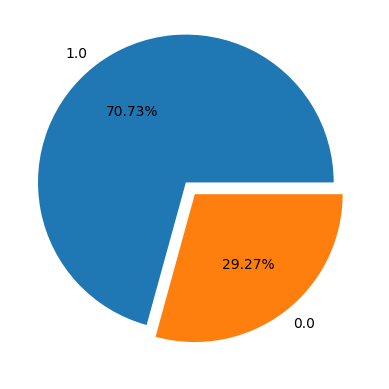

In [21]:
Target = df['dropout_MNCH'].value_counts()

plt.pie(Target, 
        labels=Target.index, 
        autopct='%1.2f%%',  
        explode=[0.1, 0])
plt.show()

In [26]:
X = df.drop(['dropout_MNCH', 'Division'], axis=1)
y = df['dropout_MNCH']

In [27]:
smote = SMOTE(random_state=123, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [28]:
pd.Series(y_resampled).value_counts()

dropout_MNCH
0.0    3542
1.0    3542
Name: count, dtype: int64

In [30]:
rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=123)
boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=100,
    random_state=123,
    verbose=2
)
X_boruta = X_resampled.values
y_boruta = y_resampled.values
boruta.fit(X_boruta, y_boruta)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	9 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	10 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	11 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	12 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	13 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	14 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	15 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	16 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	10
Iteration

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced',
                                          n_estimators=31, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x1695DF71140),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x1695DF71140, verbose=2)

In [32]:
confirmed_vars_idx = boruta.support_
confirmed_vars = X_resampled.columns[confirmed_vars_idx].tolist()
print("\nConfirmed important variables:", confirmed_vars)


Confirmed important variables: ['wealth_index', 'partner_education', 'media_exposure']


In [33]:
if len(confirmed_vars) > 0:
    X_final = X_resampled[confirmed_vars]
else:
    X_final = X_resampled
    confirmed_vars = X_resampled.columns.tolist()

y_final = y_resampled

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=123, stratify=y_final
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set class distribution: \n{pd.Series(y_train).value_counts()}")


Training set size: (5667, 3)
Test set size: (1417, 3)
Training set class distribution: 
dropout_MNCH
1.0    2834
0.0    2833
Name: count, dtype: int64


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [37]:
models = {}

In [38]:
print("\n=== Training Random Forest ===")
rf_param_grid = {
    'max_features': [2, 4, 6, 8, 10],
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=123, n_jobs=-1),
    rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
models['RandomForest'] = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")
print(f"Best RF CV AUC: {rf_grid.best_score_:.4f}")


=== Training Random Forest ===
Best RF params: {'max_depth': 10, 'max_features': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV AUC: 0.7956


In [39]:
print("\n=== Training Decision Tree ===")
dt_param_grid = {
    'ccp_alpha': np.arange(0.01, 0.51, 0.01),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=123),
    dt_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
models['DecisionTree'] = dt_grid.best_estimator_
print(f"Best DT params: {dt_grid.best_params_}")
print(f"Best DT CV AUC: {dt_grid.best_score_:.4f}")


=== Training Decision Tree ===
Best DT params: {'ccp_alpha': 0.01, 'max_depth': 5, 'min_samples_split': 2}
Best DT CV AUC: 0.7015


In [40]:
print("\n=== Training Logistic Regression ===")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=123, max_iter=1000),
    lr_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
lr_grid.fit(X_train_scaled, y_train)  # Scaled for better convergence
models['LogisticRegression'] = lr_grid.best_estimator_
print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV AUC: {lr_grid.best_score_:.4f}")


=== Training Logistic Regression ===
Best LR params: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV AUC: 0.7381


In [41]:
print("\n=== Training KNN ===")
knn_param_grid = {
    'n_neighbors': list(range(3, 16, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
knn_grid.fit(X_train_scaled, y_train)
models['KNN'] = knn_grid.best_estimator_
print(f"Best KNN params: {knn_grid.best_params_}")
print(f"Best KNN CV AUC: {knn_grid.best_score_:.4f}")


=== Training KNN ===
Best KNN params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best KNN CV AUC: 0.7524


In [42]:
print("\n=== Training SVM ===")
svm_param_grid = {
    'C': [0.25, 0.5, 1, 2],
    'gamma': [0.25, 0.5, 1, 2],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=123),
    svm_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
svm_grid.fit(X_train_scaled, y_train)
models['SVM'] = svm_grid.best_estimator_
print(f"Best SVM params: {svm_grid.best_params_}")
print(f"Best SVM CV AUC: {svm_grid.best_score_:.4f}")


=== Training SVM ===
Best SVM params: {'C': 0.5, 'gamma': 0.25, 'kernel': 'rbf'}
Best SVM CV AUC: 0.7522


In [43]:
print("\n=== Training XGBoost ===")
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=123, use_label_encoder=False, eval_metric='logloss'),
    xgb_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
models['XGBoost'] = xgb_grid.best_estimator_
print(f"Best XGBoost params: {xgb_grid.best_params_}")
print(f"Best XGBoost CV AUC: {xgb_grid.best_score_:.4f}")


=== Training XGBoost ===
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best XGBoost CV AUC: 0.7997


In [44]:
print("\n=== Training Neural Network ===")
nn_param_grid = {
    'hidden_layer_sizes': [(3,), (5,), (7,), (10,)],
    'alpha': [0.01, 0.1, 0.001],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [200]
}
nn_grid = GridSearchCV(
    MLPClassifier(random_state=123, early_stopping=True),
    nn_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
nn_grid.fit(X_train_scaled, y_train)
models['NeuralNet'] = nn_grid.best_estimator_
print(f"Best NN params: {nn_grid.best_params_}")
print(f"Best NN CV AUC: {nn_grid.best_score_:.4f}")


=== Training Neural Network ===
Best NN params: {'alpha': 0.01, 'hidden_layer_sizes': (7,), 'learning_rate_init': 0.01, 'max_iter': 200}
Best NN CV AUC: 0.7443


In [45]:
def evaluate_model(model, X_test, y_test, model_name, use_scaled=False):
    """
    Evaluate model and return metrics similar to R's evaluate_model function
    """
    if use_scaled:
        X_test_eval = X_test_scaled
    else:
        X_test_eval = X_test
    
    # Predictions
    y_pred = model.predict(X_test_eval)
    
    # Probability predictions for positive class (1)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_eval)[:, 1]
    else:
        y_prob = model.decision_function(X_test_eval)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc
    }

# Evaluate all models (keeping track of which need scaled data)
evaluation_results = []

# Models that need scaled data
scaled_models = ['LogisticRegression', 'KNN', 'SVM', 'NeuralNet']

for name, model in models.items():
    use_scaled = name in scaled_models
    results = evaluate_model(model, X_test, y_test, name, use_scaled)
    evaluation_results.append(results)

# Create results dataframe
results_df = pd.DataFrame(evaluation_results)
print("\n" + "="*60)
print("=== MODEL PERFORMANCE COMPARISON ===")
print("="*60)
print(results_df.to_string(index=False))


=== MODEL PERFORMANCE COMPARISON ===
             Model  Accuracy  Precision   Recall       F1      AUC
      RandomForest  0.736768   0.715573 0.785311 0.748822 0.813130
      DecisionTree  0.678193   0.644828 0.792373 0.711027 0.710514
LogisticRegression  0.678899   0.687407 0.655367 0.671005 0.756895
               KNN  0.692308   0.711180 0.646893 0.677515 0.761075
               SVM  0.707833   0.696524 0.735876 0.715659 0.768031
           XGBoost  0.733945   0.710828 0.788136 0.747488 0.809789
         NeuralNet  0.697953   0.691257 0.714689 0.702778 0.763796


In [46]:
print("\n" + "="*60)
print("=== DETAILED RESULTS TABLE ===")
print("="*60)
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10}")
print("-"*70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} {row['Accuracy']:<10.3f} {row['Precision']:<10.3f} {row['Recall']:<10.3f} {row['F1']:<10.3f} {row['AUC']:<10.3f}")


=== DETAILED RESULTS TABLE ===
Model                Accuracy   Precision  Recall     F1-Score   AUC       
----------------------------------------------------------------------
RandomForest         0.737      0.716      0.785      0.749      0.813     
DecisionTree         0.678      0.645      0.792      0.711      0.711     
LogisticRegression   0.679      0.687      0.655      0.671      0.757     
KNN                  0.692      0.711      0.647      0.678      0.761     
SVM                  0.708      0.697      0.736      0.716      0.768     
XGBoost              0.734      0.711      0.788      0.747      0.810     
NeuralNet            0.698      0.691      0.715      0.703      0.764     


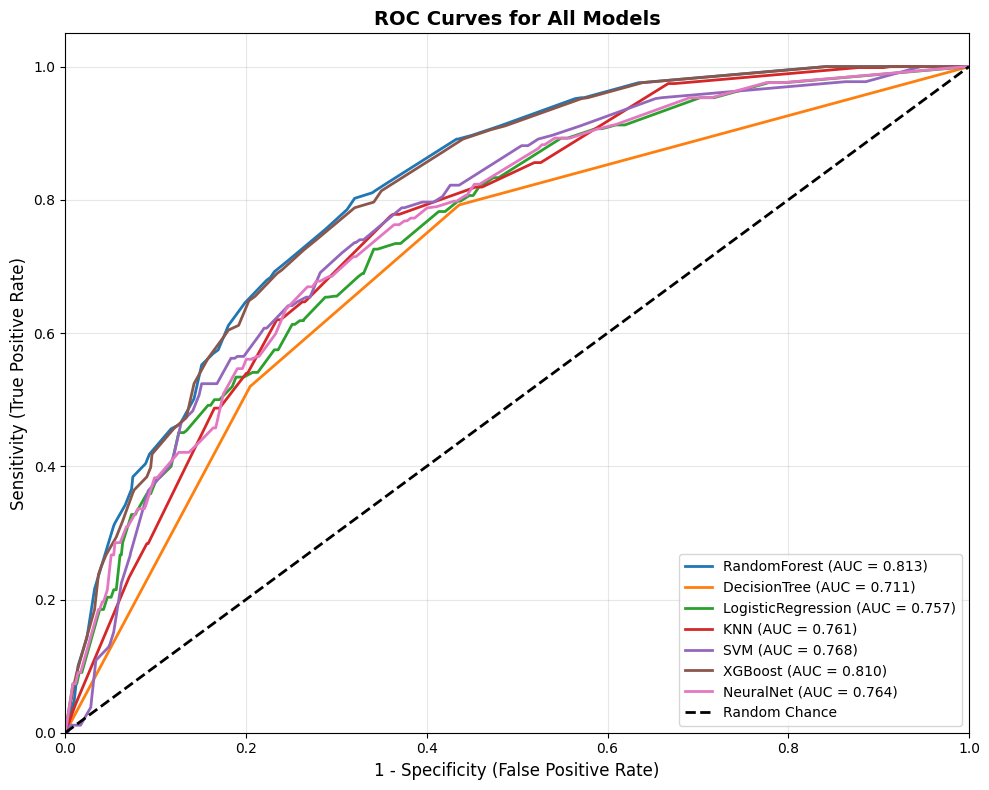


ROC curve saved as 'ROC_curve_python.png'


In [47]:
plt.figure(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, (name, model) in enumerate(models.items()):
    use_scaled = name in scaled_models
    if use_scaled:
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = model.decision_function(X_eval)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results_df[results_df['Model'] == name]['AUC'].values[0]
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ROC_curve_python.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nROC curve saved as 'ROC_curve_python.png'")

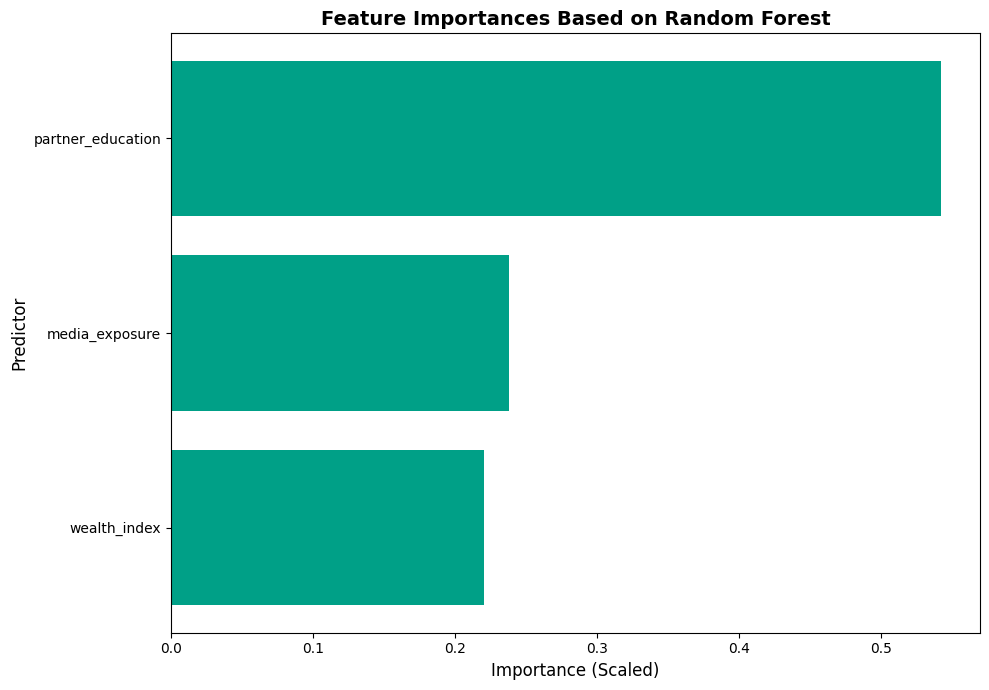


Feature importance plot saved as 'varimp_RF_python.png'

Feature Importance Values:
         Variable  Overall
partner_education 0.542227
   media_exposure 0.237533
     wealth_index 0.220241


In [48]:
rf_best = models['RandomForest']

if hasattr(rf_best, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Variable': confirmed_vars,
        'Overall': rf_best.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Overall', ascending=True)
    
    plt.figure(figsize=(10, 7))
    bars = plt.barh(feature_importance['Variable'], feature_importance['Overall'], color='#00A087')
    plt.xlabel('Importance (Scaled)', fontsize=12)
    plt.ylabel('Predictor', fontsize=12)
    plt.title('Feature Importances Based on Random Forest', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('varimp_RF_python.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nFeature importance plot saved as 'varimp_RF_python.png'")
    print("\nFeature Importance Values:")
    print(feature_importance.sort_values('Overall', ascending=False).to_string(index=False))

<Figure size 600x500 with 0 Axes>

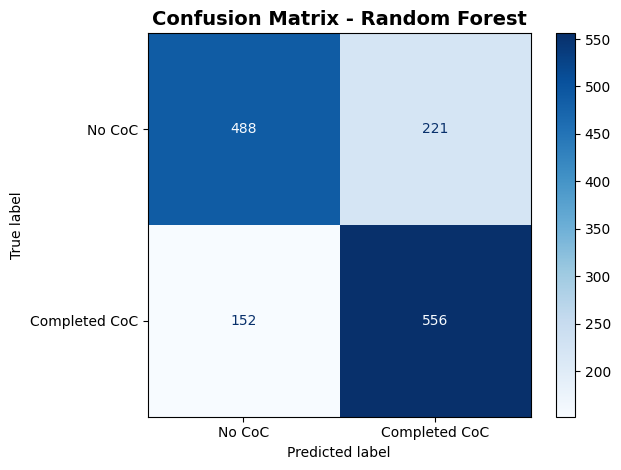


=== BEST HYPERPARAMETERS FROM ALL MODELS ===

RandomForest:
  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 4, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False}

DecisionTree:
  {'ccp_alpha': 0.01, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'}

LogisticRegression:
  {'C': 0.001, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'ra

In [49]:
# Show confusion matrix for Random Forest
y_pred_rf = rf_best.predict(X_test)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CoC', 'Completed CoC'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_python.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("=== BEST HYPERPARAMETERS FROM ALL MODELS ===")
print("="*60)
for name, model in models.items():
    print(f"\n{name}:")
    print(f"  {model.get_params()}")

print("\n" + "="*60)
print("=== ANALYSIS COMPLETE ===")
print("="*60)
print("Generated files:")
print("  - ROC_curve_python.png")
print("  - varimp_RF_python.png")
print("  - shap_plot_python.png")
print("  - shap_barplot_python.png")
print("  - calibration_plot_python.png")
print("  - confusion_matrix_python.png")

Training Stacking Ensemble...
Training completed!

Training Random Forest...
Training XGBoost...
Training SVM...
Training Decision Tree...
Training KNN...

MODEL PERFORMANCE COMPARISON
             Model  Accuracy  Precision   Recall  F1-Score      AUC
     Random Forest  0.736768   0.715573 0.785311  0.748822 0.812851
           XGBoost  0.733945   0.711908 0.785311  0.746810 0.808837
               SVM  0.499647   0.499647 1.000000  0.666353 0.646407
     Decision Tree  0.678193   0.644828 0.792373  0.711027 0.710514
               KNN  0.642202   0.687850 0.519774  0.592116 0.677206
Stacking (LR meta)  0.741002   0.714465 0.802260  0.755822 0.810930

IMPROVEMENT FROM STACKING

Best Base Model: Random Forest
  Accuracy: 0.7368
  AUC: 0.8129

Stacking Ensemble (Meta: Logistic Regression):
  Accuracy: 0.7410
  AUC: 0.8109

Improvement:
  Accuracy: +0.42%
  AUC: +-0.19%

TABLE: MODEL PERFORMANCE METRICS
Model                Accuracy   Precision  Recall     F1-Score   AUC       
--------

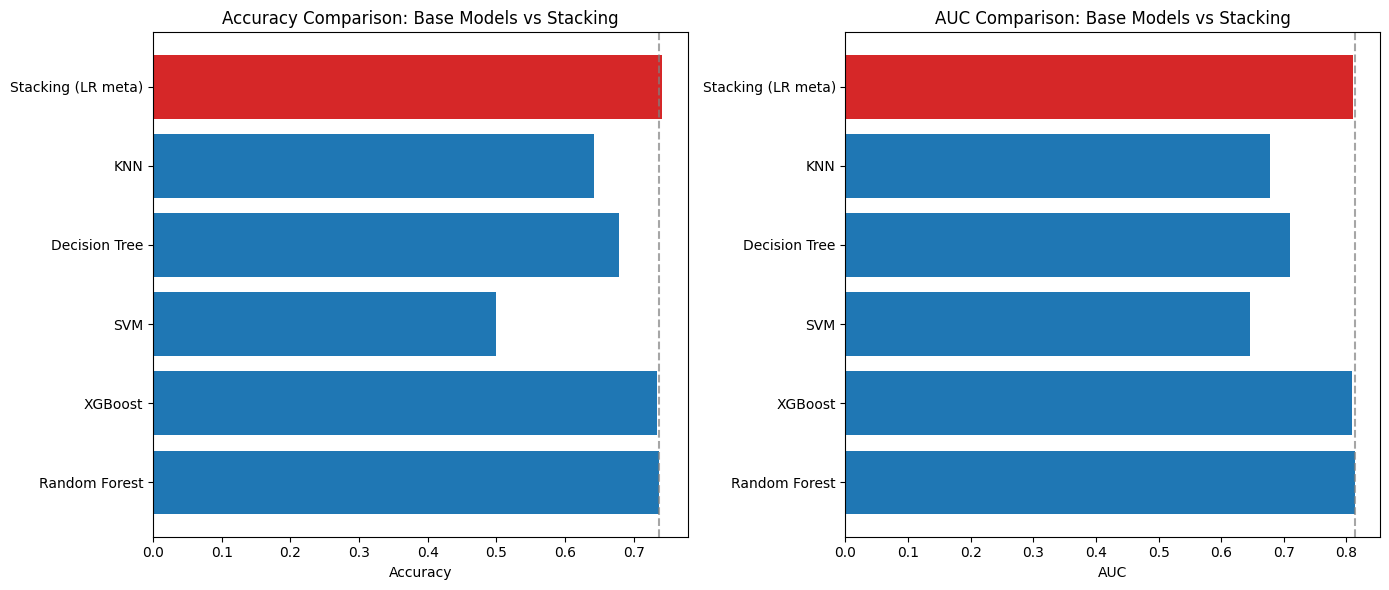


COMPARISON PLOT SAVED: stacking_comparison.png


In [50]:
# ============================================
# STACKING ENSEMBLE WITH META-LEARNER LR
# Base Models: RF, XGBoost, SVM, DT, KNN
# ============================================

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

np.random.seed(123)

# ============================================
# 1. DEFINE BASE MODELS (with best hyperparameters from tuning)
# ============================================

base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_features=6,
        max_depth=20,
        random_state=123,
        n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=123,
        eval_metric='logloss'
    )),
    ('svm', SVC(
        C=1,
        gamma=0.5,
        probability=True,
        random_state=123
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=15,
        ccp_alpha=0.01,
        random_state=123
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='euclidean'
    ))
]

# ============================================
# 2. DEFINE META-LEARNER (Logistic Regression)
# ============================================

meta_learner = LogisticRegression(
    C=1,
    penalty='l2',
    solver='lbfgs',
    random_state=123,
    max_iter=1000
)

# ============================================
# 3. CREATE STACKING CLASSIFIER
# ============================================

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,                    # 5-fold cross-validation for meta-features
    stack_method='predict_proba',  # Use probabilities for stacking
    passthrough=False        # Don't pass original features to meta-learner
)

# ============================================
# 4. TRAIN THE MODEL
# ============================================

print("Training Stacking Ensemble...")
stacking_clf.fit(X_train, y_train)
print("Training completed!\n")

# ============================================
# 5. EVALUATION FUNCTION
# ============================================

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_prob)
    }
    return metrics

# ============================================
# 6. EVALUATE ALL MODELS (Base + Stacking)
# ============================================

all_models = {
    'Random Forest': base_models[0][1],
    'XGBoost': base_models[1][1],
    'SVM': base_models[2][1],
    'Decision Tree': base_models[3][1],
    'KNN': base_models[4][1],
    'Stacking (LR meta)': stacking_clf
}

# Train base models individually (if not already trained)
results = []

for name, model in all_models.items():
    if name != 'Stacking (LR meta)':  # Base models need to be trained
        print(f"Training {name}...")
        model.fit(X_train, y_train)
    
    metrics = evaluate_model(model, X_test_scaled if name=='SVM' or name=='KNN' else X_test, 
                            y_test, name)
    results.append(metrics)

# Create results dataframe
results_df = pd.DataFrame(results)

# ============================================
# 7. PRINT RESULTS
# ============================================

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("IMPROVEMENT FROM STACKING")
print("="*70)

# Find best base model
base_df = results_df[results_df['Model'] != 'Stacking (LR meta)']
best_base = base_df.loc[base_df['AUC'].idxmax()]
stacking_result = results_df[results_df['Model'] == 'Stacking (LR meta)'].iloc[0]

print(f"\nBest Base Model: {best_base['Model']}")
print(f"  Accuracy: {best_base['Accuracy']:.4f}")
print(f"  AUC: {best_base['AUC']:.4f}")

print(f"\nStacking Ensemble (Meta: Logistic Regression):")
print(f"  Accuracy: {stacking_result['Accuracy']:.4f}")
print(f"  AUC: {stacking_result['AUC']:.4f}")

print(f"\nImprovement:")
print(f"  Accuracy: +{(stacking_result['Accuracy'] - best_base['Accuracy'])*100:.2f}%")
print(f"  AUC: +{(stacking_result['AUC'] - best_base['AUC'])*100:.2f}%")

# ============================================
# 8. COMPARISON TABLE (Like paper's Table 2)
# ============================================

print("\n" + "="*70)
print("TABLE: MODEL PERFORMANCE METRICS")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10}")
print("-"*70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} {row['Accuracy']:<10.4f} {row['Precision']:<10.4f} {row['Recall']:<10.4f} {row['F1-Score']:<10.4f} {row['AUC']:<10.4f}")

# ============================================
# 9. VISUALIZATION: BAR PLOT COMPARISON
# ============================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
colors = ['#1f77b4']*5 + ['#d62728']
axes[0].barh(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy Comparison: Base Models vs Stacking')
axes[0].axvline(x=best_base['Accuracy'], linestyle='--', color='gray', alpha=0.7)

# AUC comparison
axes[1].barh(results_df['Model'], results_df['AUC'], color=colors)
axes[1].set_xlabel('AUC')
axes[1].set_title('AUC Comparison: Base Models vs Stacking')
axes[1].axvline(x=best_base['AUC'], linestyle='--', color='gray', alpha=0.7)

plt.tight_layout()
plt.savefig('stacking_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("COMPARISON PLOT SAVED: stacking_comparison.png")
print("="*70)